In [ ]:
# ===== HOMEWORK STARTER CODE — fill in every # TODO =====
# Carga de librerías
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, roc_auc_score,
                             confusion_matrix, classification_report, RocCurveDisplay)
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
# Generación de la semilla
RANDOM_STATE = 42

In [ ]:
# --- TODO 1: download and inspect -----------------------------------------
URL_HW = "https://archive.ics.uci.edu/ml/machine-learning-databases/parkinsons/telemonitoring/parkinsons_updrs.data"
Local_path="parkinsons_updrs.data"
urllib.request.urlretrieve(URL_HW, "parkinsons_updrs.data")
print("Downloaded: ", Local_path)
df_hw = pd.read_csv(Local_path)
print("Shape:", df_hw.shape)
df_hw.head()

# TODO 1a: print shape, columns, and number of unique subjects
print("Shape:", df_hw.shape)
print("Columns:", list(df_hw.columns))
print("Unique subjects:", df_hw["subject#"].nunique())

Downloaded:  parkinsons_updrs.data
Shape: (5875, 22)
Shape: (5875, 22)
Columns: ['subject#', 'age', 'sex', 'test_time', 'motor_UPDRS', 'total_UPDRS', 'Jitter(%)', 'Jitter(Abs)', 'Jitter:RAP', 'Jitter:PPQ5', 'Jitter:DDP', 'Shimmer', 'Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'Shimmer:APQ11', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'PPE']
Unique subjects: 42


In [ ]:
# --- TODO 2: create the binary target --------------------------------------
median_updrs = df_hw["total_UPDRS"].median()
df_hw["high_severity"] = (df_hw["total_UPDRS"] > median_updrs).astype(int)

# --- prepare X, y, and the grouping variable ------------------------------
# Keep subject# only for grouping; drop both regression targets.
X_hw = df_hw.drop(columns=["motor_UPDRS", "total_UPDRS", "high_severity"])
groups = X_hw["subject#"].values
y_hw = df_hw["high_severity"].values
X_hw = X_hw.drop(columns=["subject#"])

print("Columns:", list(df_hw.columns))
print("\nClass balance (high_severity: 1 = high, 0 = low):")
print(df_hw["high_severity"].value_counts())
print("\nMissing values:", int(df_hw.isna().sum().sum()))
print("\nFeature scales (min/max of a few columns):")
df_hw.describe().T[["min", "max", "mean"]].head(8)

Columns: ['subject#', 'age', 'sex', 'test_time', 'motor_UPDRS', 'total_UPDRS', 'Jitter(%)', 'Jitter(Abs)', 'Jitter:RAP', 'Jitter:PPQ5', 'Jitter:DDP', 'Shimmer', 'Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'Shimmer:APQ11', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'PPE', 'high_severity']

Class balance (high_severity: 1 = high, 0 = low):
high_severity
0    2941
1    2934
Name: count, dtype: int64

Missing values: 0

Feature scales (min/max of a few columns):


,min,max,mean
subject#,1.000000,42.000000,21.494128
age,36.000000,85.000000,64.804936
sex,0.000000,1.000000,0.317787
test_time,-4.262500,215.490000,92.863722
motor_UPDRS,5.037700,39.511000,21.296229
total_UPDRS,7.000000,54.992000,29.018942
Jitter(%),0.000830,0.099990,0.006154
Jitter(Abs),0.000002,0.000446,0.000044


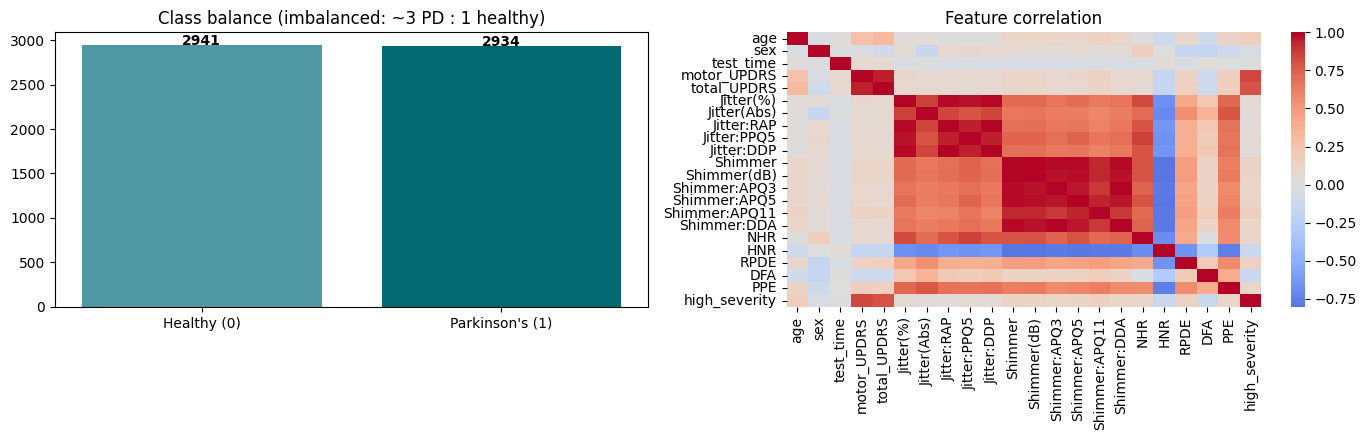

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Class balance
counts = df_hw["high_severity"].value_counts().sort_index()
axes[0].bar(["Healthy (0)", "Parkinson's (1)"], counts.values, color=["#4F98A3", "#01696F"])
axes[0].set_title("Class balance (imbalanced: ~3 PD : 1 healthy)")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1, str(v), ha="center", fontweight="bold")

# Correlation heatmap (drop the subject 'name' column)
num = df_hw.drop(columns=["subject#"])
sns.heatmap(num.corr(), cmap="coolwarm", center=0, ax=axes[1], cbar=True)
axes[1].set_title("Feature correlation")
plt.tight_layout()
plt.show()

In [ ]:
# --- TODO 3: grouped train/test split (no shared subjects) -----------------
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X_hw, y_hw, groups))
X_train_hw, X_test_hw = X_hw.iloc[train_idx], X_hw.iloc[test_idx]
y_train_hw, y_test_hw = y_hw[train_idx], y_hw[test_idx]

# Sanity check: confirm train and test share NO subjects
train_subjects = set(groups[train_idx]); test_subjects = set(groups[test_idx])
assert len(train_subjects & test_subjects) == 0, "Patient leakage detected!"
print(f"Train: {X_train_hw.shape}  Test: {X_test_hw.shape}  (subjects: train={len(train_subjects)}, test={len(test_subjects)})")


Train: (4640, 19)  Test: (1235, 19)  (subjects: train=33, test=9)


In [ ]:
# --- TODO 4: reuse the four pipelines + grouped CV tuning ------------------
def make_pipeline(model):
    return Pipeline([("scaler", StandardScaler()),
                     ("smote", SMOTE(random_state=RANDOM_STATE)),
                     ("clf", model)])

models_hw = {
    "LogisticRegression": (LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
                           {"clf__C": [0.1, 1, 10], "clf__class_weight": [None, "balanced"]}),
    "SVM": (SVC(probability=True, random_state=RANDOM_STATE),
            {"clf__C": [0.1, 1, 10], "clf__gamma": ["scale", "auto"]}),
    "RandomForest": (RandomForestClassifier(random_state=RANDOM_STATE),
                     {"clf__n_estimators": [200, 400], "clf__max_depth": [None, 8, 16]}),
    "XGBoost": (XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE),
                {"clf__n_estimators": [200, 400], "clf__max_depth": [3, 6],
                 "clf__learning_rate": [0.05, 0.1]}),
}

# Hint: use GroupKFold on the TRAINING subjects for inner CV.
from sklearn.model_selection import GroupKFold
gcv = GroupKFold(n_splits=5)

best_hw = {}
for name, (model, grid) in models_hw.items():
    search = GridSearchCV(make_pipeline(model), grid, scoring="roc_auc", cv=gcv, n_jobs=-1)
    # NOTE: GroupKFold needs the groups argument in fit()
    search.fit(X_train_hw, y_train_hw, groups=groups[train_idx])
    best_hw[name] = search.best_estimator_
    print(f"{name:20s} best grouped-CV ROC-AUC = {search.best_score_:.3f}")


LogisticRegression   best grouped-CV ROC-AUC = 0.633
SVM                  best grouped-CV ROC-AUC = 0.557
RandomForest         best grouped-CV ROC-AUC = 0.479
XGBoost              best grouped-CV ROC-AUC = 0.513


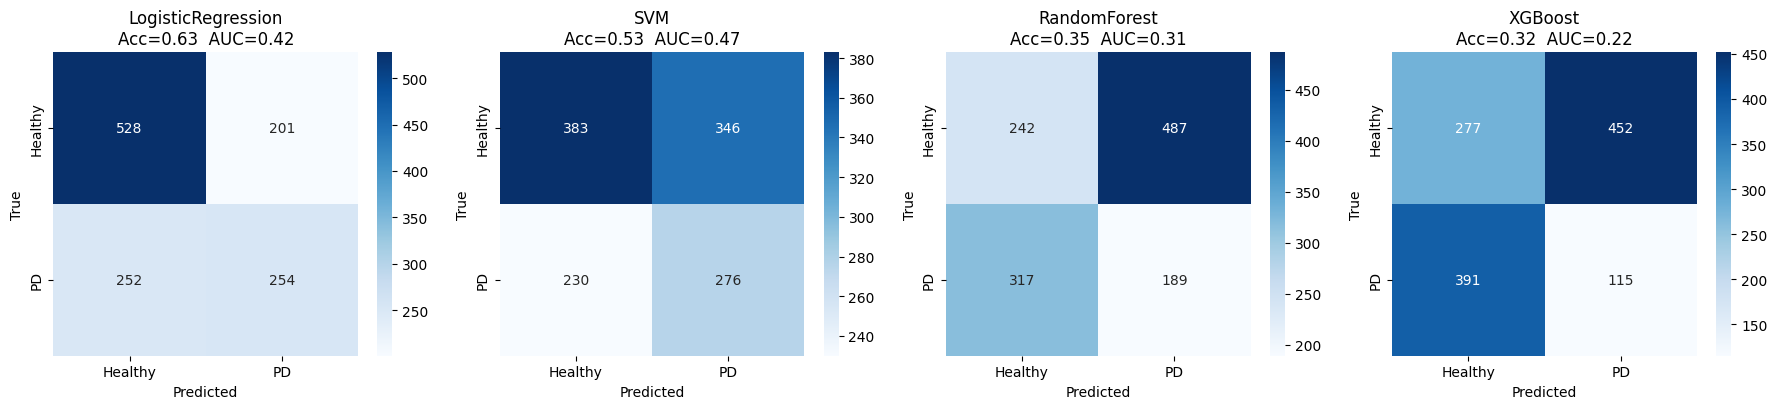

,Model,Accuracy,Balanced Acc,ROC-AUC
0,SVM,0.533603,0.535416,0.465137
1,LogisticRegression,0.633198,0.613128,0.422686
2,RandomForest,0.348988,0.352740,0.310987
3,XGBoost,0.317409,0.303623,0.221149


In [ ]:
# TODO 4b: evaluate each model on the held-out test set
#           (accuracy, balanced accuracy, ROC-AUC, confusion matrix) and
#           build a comparison DataFrame.
results = []
fig, axes = plt.subplots(1, len(best_hw), figsize=(18, 4.2))
for ax, (name, model) in zip(axes, best_hw.items()):
    y_pred = model.predict(X_test_hw)
    y_proba = model.predict_proba(X_test_hw)[:, 1]
    acc = accuracy_score(y_test_hw, y_pred)
    bacc = balanced_accuracy_score(y_test_hw, y_pred)
    auc = roc_auc_score(y_test_hw, y_proba)
    results.append({"Model": name, "Accuracy": acc, "Balanced Acc": bacc, "ROC-AUC": auc})
    cm = confusion_matrix(y_test_hw, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Healthy", "PD"], yticklabels=["Healthy", "PD"])
    ax.set_title(f"{name}\nAcc={acc:.2f}  AUC={auc:.2f}")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.tight_layout(); plt.show()

results_df = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
results_df

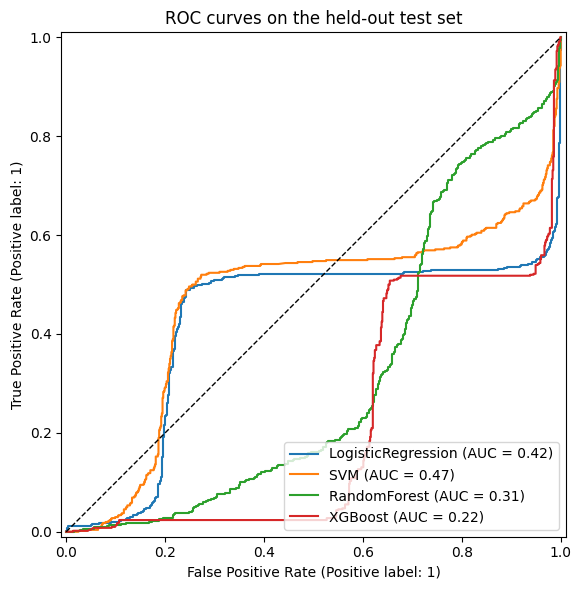

Best model: SVM

              precision    recall  f1-score   support

     Healthy       0.62      0.53      0.57       729
 Parkinson's       0.44      0.55      0.49       506

    accuracy                           0.53      1235
   macro avg       0.53      0.54      0.53      1235
weighted avg       0.55      0.53      0.54      1235



In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, model in best_hw.items():
    RocCurveDisplay.from_estimator(model, X_test_hw, y_test_hw, name=name, ax=ax)
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("ROC curves on the held-out test set")
plt.tight_layout(); plt.show()

# Full report for the best model
best_name = results_df.iloc[0]["Model"]
print(f"Best model: {best_name}\n")
print(classification_report(y_test_hw, best_hw[best_name].predict(X_test_hw),
                            target_names=["Healthy", "Parkinson's"]))

In [ ]:
# --- TODO 5: leakage experiment -------------------------------------------
# Train XGBoost on a NAIVE random 80/20 split (same patients in train and test).
from sklearn.model_selection import train_test_split as _tts
X_tr_leak, X_te_leak, y_tr_leak, y_te_leak = _tts(
    X_hw, y_hw, test_size=0.2, random_state=RANDOM_STATE)   # <-- NOT grouped!
leaky_pipe = make_pipeline(XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE,
                                          n_estimators=200, max_depth=3, learning_rate=0.1))
leaky_pipe.fit(X_tr_leak, y_tr_leak)
leaky_auc = roc_auc_score(y_te_leak, leaky_pipe.predict_proba(X_te_leak)[:, 1])
print(f"LEAKY (random split) XGBoost test ROC-AUC = {leaky_auc:.3f}")
# Compare this number to your grouped-split XGBoost AUC above.

LEAKY (random split) XGBoost test ROC-AUC = 0.989


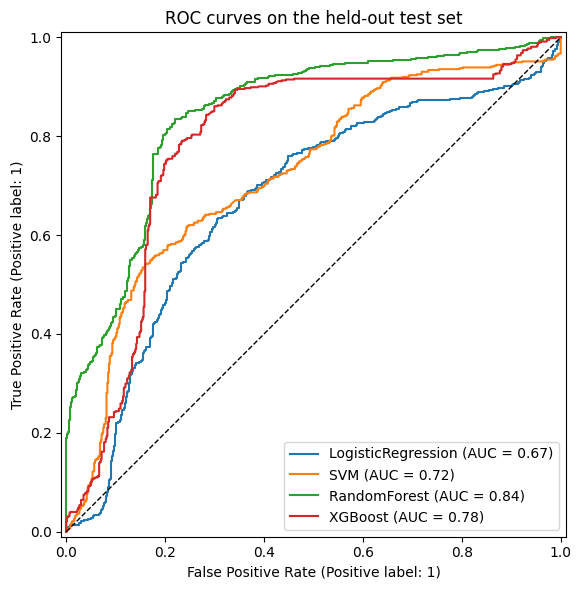

Best model: SVM

              precision    recall  f1-score   support

     Healthy       0.62      0.53      0.57       729
 Parkinson's       0.44      0.55      0.49       506

    accuracy                           0.53      1235
   macro avg       0.53      0.54      0.53      1235
weighted avg       0.55      0.53      0.54      1235



In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, model in best_hw.items():
    RocCurveDisplay.from_estimator(model, X_te_leak, y_te_leak, name=name, ax=ax)
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("ROC curves on the held-out test set")
plt.tight_layout(); plt.show()

# Full report for the best model
best_name = results_df.iloc[0]["Model"]
print(f"Best model: {best_name}\n")
print(classification_report(y_test_hw, best_hw[best_name].predict(X_test_hw),
                            target_names=["Healthy", "Parkinson's"]))

### TODO 6 — Reflection (answer in a markdown cell in your notebook)

1. How much higher is the **leaky** AUC than the **grouped** AUC? Explain *why* a random split inflates
   performance (hint: the model memorizes per-patient voice signatures instead of generalizing to
   unseen patients).
2. Which model generalizes best to **unseen patients**?
3. Why is patient-level splitting essential when a dataset contains repeated recordings per subject?
4. Name two other sources of leakage in medical ML besides repeated measurements.
5. If you had to deploy this model in a clinic, what additional validation would you require
   (e.g. external site, different demographics) before trusting it?

---

### Respuestas

**1. Brecha leaky vs. agrupado.** El XGBoost con split aleatorio (leaky) obtuvo **AUC = 0.989**, mientras
que el mismo XGBoost con split agrupado por paciente obtuvo apenas **AUC = 0.221** en test (CV agrupada:
0.513). La brecha es de más de 0.7 en test. Esto pasa porque con un split aleatorio, grabaciones del
*mismo* paciente terminan repartidas entre train y test: el modelo no aprende un patrón biomédico que
generalice, aprende a reconocer la "firma de voz" individual de cada paciente (tono base, timbre, forma
de hablar) y luego simplemente la reconoce en test porque ya la vio en train. Es memorización de
identidad, no detección real de severidad.

**2. Mejor modelo en pacientes no vistos.** Entre los cuatro, SVM tuvo el AUC de test más alto
(0.465), seguido de LogisticRegression (0.423), RandomForest (0.311) y XGBoost (0.221). Sin embargo,
con solo **9 pacientes en el test set**, ninguno de estos números es confiablemente distinto de 0.5
(azar): la varianza de un AUC calculado sobre tan pocas unidades independientes es enorme. La
conclusión honesta es que, con las features de voz disponibles, ningún modelo generaliza de forma
robusta a pacientes nuevos para este target (`high_severity` por mediana de `total_UPDRS`) — no que
"SVM es mejor".

**3. Por qué separar por paciente.** Un mismo paciente aporta muchas grabaciones repetidas cuyos
rasgos acústicos están altamente correlacionados entre sí (misma voz, mismo aparato fonador, condición
similar de una sesión a otra cercana en el tiempo). Si se permite que el mismo paciente aparezca en
train y test, el modelo puede "reconocer" a ese paciente en vez de aprender el patrón general
enfermedad→voz, y el desempeño en test queda artificialmente inflado y no dice nada sobre cómo se
comportaría el modelo con una persona que nunca ha visto.

**4. Otras dos fuentes de leakage en ML médico:**
   - **Preprocesamiento ajustado con todo el dataset:** normalizar, imputar o seleccionar features
     usando estadísticos (media, desviación estándar, etc.) calculados sobre train+test antes de
     dividir, en vez de ajustar el preprocesamiento solo en train. Filtra información de la
     distribución del test hacia el entrenamiento.
   - **Leakage de sitio/equipo:** si, por ejemplo, todos los casos positivos vienen de un hospital o
     un micrófono/equipo distinto al de los casos negativos, el modelo puede aprender a distinguir el
     equipo de grabación (o artefactos de compresión, metadata, etc.) en lugar de la señal clínica real.

**5. Validación adicional antes de usarlo en clínica:** (a) validación externa con pacientes de
   otro(s) sitio(s)/equipo(s) de grabación, no solo un split interno del mismo estudio; (b) validación
   en poblaciones con demografía distinta (rango de edad, sexo, etapa de la enfermedad, idioma/acento)
   a la de este dataset (42 sujetos, mayormente en una etapa específica de monitoreo); (c) validación
   prospectiva (pacientes futuros, no solo un hold-out retrospectivo) y monitoreo de *drift* del modelo
   en producción; y (d) revisión clínica conjunta con un neurólogo para confirmar que las predicciones
   son clínicamente accionables y no solo estadísticamente significativas.

---

### Further reading
- [UCI Parkinson's (voice) dataset](https://archive.ics.uci.edu/dataset/174/parkinsons)
- [UCI Parkinson's Telemonitoring dataset](https://archive.ics.uci.edu/dataset/189/parkinsons+telemonitoring)
- [imbalanced-learn — SMOTE](https://imbalanced-learn.org/stable/over_sampling.html)
- [Scikit-learn — common pitfalls](https://scikit-learn.org/stable/common_pitfalls.html)
- [XGBoost paper (Chen & Guestrin, 2016)](https://arxiv.org/abs/1603.02754)

*End of Lab 1. Next: Session 3 — Deep Learning & CNNs.*